In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

"""Backend: pytorch"""
import torch

# FNO functions
import sampler

from scipy.interpolate import interp1d
from scipy.interpolate import griddata 

import warnings
from tqdm import tqdm
import time

In [2]:
%cd /home/jw3275/Characteristics-Net

import utils

%cd /home/jw3275/neuraloperator/scripts/fno_inviscid

/home/jw3275/Characteristics-Net
/home/jw3275/neuraloperator/scripts/fno_inviscid


In [3]:
%cd /home/jw3275/neuraloperator

from config.burgers_pino_config import Default
from neuralop import get_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Default()
config = config.to_dict()

model = get_model(config).to(device)


/home/jw3275/neuraloperator


In [4]:
import torch
import neuralop.layers.spectral_convolution as sc

torch.serialization.add_safe_globals([sc.SpectralConv])
torch.serialization.add_safe_globals([torch._C._nn.gelu])


In [5]:
state_dict = torch.load(
    "/home/jw3275/neuraloperator/scripts/pino_burgers_v_001_last_model_res_100_modified_ite_10000.pt",
    map_location=device,
    weights_only=False
)

model.load_state_dict(state_dict)
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [6]:
import numpy as np
import torch

def fno_predict_u(model, v_branch, x_grid, t_grid, device):
    """
    v_branch: (Nx,)  initial condition
    x_grid:   (Nx,)
    t_grid:   (Nt,)
    returns: u_pred (Nt, Nx)
    """
    model.eval()

    with torch.no_grad():
        Nx_eval = x_grid.shape[0]
        Nt_eval = t_grid.shape[0]

        # convert to torch
        v = torch.tensor(v_branch, dtype=torch.float32, device=device)
        x = torch.tensor(x_grid,    dtype=torch.float32, device=device)
        t = torch.tensor(t_grid,    dtype=torch.float32, device=device)

        print("v shape: ", v.shape)
        print("x shape: ", x.shape)
        print("t shape: ", t.shape)

        # tile along time/space to form grids
        v_tile = v.unsqueeze(0).unsqueeze(0).repeat(1, Nt_eval, 1)   # (1, Nt, Nx)
        x_tile = x.unsqueeze(0).unsqueeze(0).repeat(1, Nt_eval, 1)
        t_tile = t[None, :, None].repeat(1, 1, Nx_eval)

        print("v tile shape: ", v_tile.shape)
        print("x tile shape: ", x_tile.shape)
        print("t tile shape: ", t_tile.shape)

        # stack into input tensor
        inp = torch.stack([v_tile, t_tile, x_tile], dim=1)          # (1, 3, Nt, Nx)

        u_pred = model(torch.stack([v_tile]))                                         # (1, 1, Nt, Nx)
        u_pred = u_pred[0, 0].cpu().numpy()

    return u_pred


In [7]:
%cd /home/jw3275/neuraloperator

import torch
import numpy as np
import matplotlib.pyplot as plt

from config.burgers_pino_config import Default
from neuralop import get_model
import neuralop.layers.spectral_convolution as sc

# ---------------------------------------
# Device
# ---------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------
# Load config (NO CLI parsing)
# ---------------------------------------
# config = Default()
# config = config.to_dict()

# # ---------------------------------------
# # Allowlist custom NeuralOperator layers (required in PyTorch 2.6)
# # ---------------------------------------
# torch.serialization.add_safe_globals([sc.SpectralConv])
# torch.serialization.add_safe_globals([torch._C._nn.gelu])

# ---------------------------------------
# Load FULL model checkpoint (NOT state_dict)
# ---------------------------------------
# model = torch.load(
#     "/home/jw3275/neuraloperator/scripts/pino_burgers_last_model_Relobralo.pt",
#     map_location=device,
#     weights_only=False
# )

# #model = model.to(device)
# model.eval()

# print("Model loaded successfully.")

# ---------------------------------------
# Numerical viscous Burgers solution
# ---------------------------------------
def solve_viscous_burgers(ic, nu=1e-2, Nx=400, Nt=400, plot=False):
    import numpy as np
    import matplotlib.pyplot as plt

    x = np.linspace(0, 1, Nx)
    dx = x[1] - x[0]
    dt = 0.5 * dx**2 / nu   # stable for implicit diffusion

    u = ic(x)
    u_vals = [u.copy()]

    # Precompute Fourier wave numbers
    k = np.fft.fftfreq(Nx, d=dx)

    for _ in range(Nt):
        u_p1 = np.roll(u, -1)
        u_m1 = np.roll(u, 1)

        # Lax–Friedrichs convection flux
        f = (u_p1**2 - u_m1**2) / (2*dx)

        # Construct RHS for implicit diffusion
        rhs = u - dt * f

        # Implicit solve in Fourier space
        rhs_hat = np.fft.fft(rhs)
        denom = 1 + dt * nu * (2*np.pi*k)**2
        u = np.real(np.fft.ifft(rhs_hat / denom))

        u_vals.append(u.copy())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(x, u_vals[0], '--', label="Initial")
        plt.plot(x, u_vals[-1], label="Final")
        plt.legend()
        plt.grid()
        plt.title("Viscous Burgers (ν={})".format(nu))
        plt.show()

    return u_vals



# ---------------------------------------
# Prediction function
# ---------------------------------------
def fno_predict_u(model, v_branch, x_grid, t_grid, device):
    model.eval()
    with torch.no_grad():
        Nx_eval = len(x_grid)
        Nt_eval = len(t_grid)

        v = torch.tensor(v_branch, device=device).float()         # (Nx,)
        x = torch.tensor(x_grid, device=device).float()           # (Nx,)
        t = torch.tensor(t_grid, device=device).float()           # (Nt,)

        # tile to (1, Nt, Nx)
        v_tile = v[None, None, :].repeat(1, Nt_eval, 1)
        x_tile = x[None, None, :].repeat(1, Nt_eval, 1)
        t_tile = t[None, :, None].repeat(1, 1, Nx_eval)

        inp = torch.stack([v_tile, t_tile, x_tile], dim=1)        # (1,3,Nt,Nx)

        u_pred = model(inp)
        return u_pred[0, 0].cpu().numpy()


# ---------------------------------------
# Generate numerical solution
# ---------------------------------------
ic = lambda x: np.sin(2*np.pi*x)
num_sol = solve_viscous_burgers(ic, nu=1e-2)

# ---------------------------------------
# Prepare grids for FNO
# ---------------------------------------
Nx = 128
Nt = 101
x_grid = np.linspace(0, 1, Nx)
t_grid = np.linspace(0, 1, Nt)

v_branch = ic(x_grid)

# ---------------------------------------
# Predict using FNO
# ---------------------------------------
u_pred = fno_predict_u(model, v_branch, x_grid, t_grid, device)

# ---------------------------------------
# Compare final-time solution
# ---------------------------------------
plt.figure(figsize=(8,5))
plt.plot(x_grid, num_sol[-1], label="Numerical (viscous Burgers)")
plt.plot(x_grid, u_pred[-1], '--', label="PINO/FNO Prediction")
plt.legend()
plt.grid(True)
plt.title("Comparison at Final Time")
plt.show()


/home/jw3275/.conda/envs/fno/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/jw3275/neuraloperator


RuntimeError: Given groups=1, weight of size [256, 3, 1], expected input[1, 5, 12928] to have 3 channels, but got 5 channels instead

Ground Truth
[solve_viscous_burgers] dx=3.906e-03, dt=4.000e-05, steps=25000, dt_conv=2.775e-03, dt_diff=7.629e-04


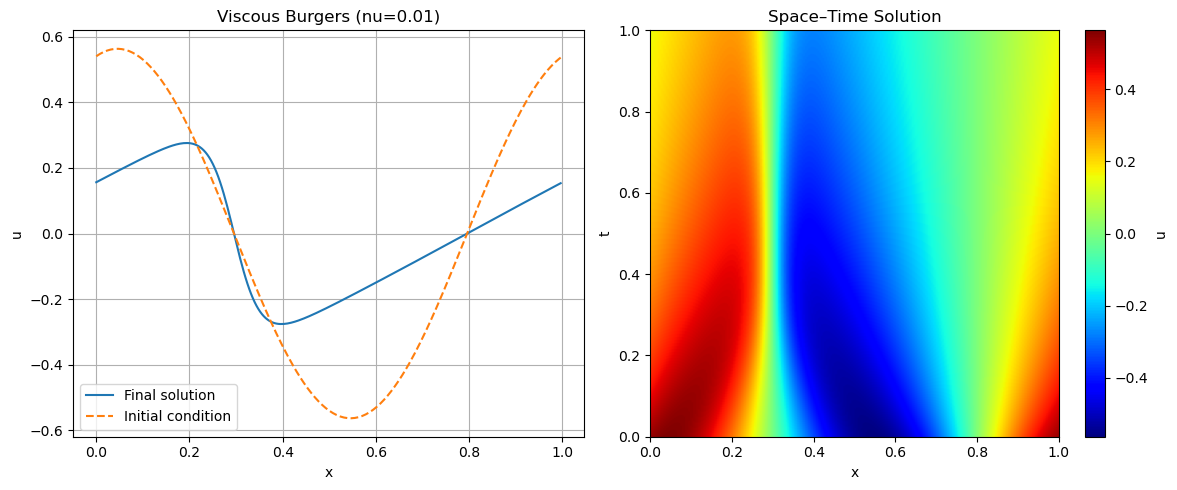

Predict
v shape:  torch.Size([256])
x shape:  torch.Size([256])
t shape:  torch.Size([1251])
v tile shape:  torch.Size([1, 1251, 256])
x tile shape:  torch.Size([1, 1251, 256])
t tile shape:  torch.Size([1, 1251, 256])


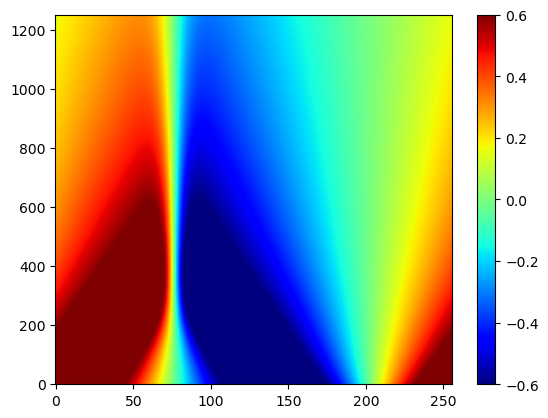

L2-relative erros:  0.4689250689560019
L1-relative erros:  0.3679753574648723


In [8]:
# Example usage

print("Ground Truth")
ic = lambda x : np.sin(2*np.pi*x)+np.cos(2*np.pi*x+np.ones_like(x))
#u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=1, Nx=256*2, Nt=5000, plot=True) 


# Viscosity should match the PDE you trained PINO on (nu=0.01 here)
u_0 = utils.numericals.solve_viscous_burgers_001(
    ic,
    nu=1e-2,          # match the nu in your BurgersEqnLoss
    x_max=1.0,
    t_max=1.0,
    Nx=256,        
    Nt=5000,         # target; function may internally increase steps for stability
    CFL=0.4,
    plot=True,
)

# Compute L2-relative error
u_0 = np.array(u_0)[::20, :]   # shape: (Nt', 256)
Nt, Nx = u_0.shape


# Compute L2-relative error
#u_0 = np.array(u_0)[::20, ::2]
#Nt, Nx = u_0.shape

print("Predict")

n_pts_edge = 256
eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)
v_branch = ic(eval_pts)

# grid of predictions

x_grid = np.linspace(0, 1.0, num=Nx)
t_grid = np.linspace(0, 1.0, num=Nt)

y_preds = fno_predict_u(model, v_branch, x_grid, t_grid, device)

# y = np.asarray(y_preds)
# if y.ndim == 2 and y.shape[1] > 1:
#     y = y[:, 1]  # u channel
# y_pred = y.reshape(n_time, n_curves)

plt.figure()
plt.imshow(y_preds, origin="lower", aspect="auto", cmap="jet", vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

print("L2-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99, ord=1))

In [9]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

abs_l2 = np.linalg.norm(u_pred - u_true)
print("Absolute L2:", abs_l2)


Absolute L2: 81.02525862413897


In [10]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

ic_norm = np.linalg.norm(u_true[0])   # t=0 slice
rel_l2_ic = np.linalg.norm(u_pred - u_true) / ic_norm
print("Relative L2 (IC scale):", rel_l2_ic)


Relative L2 (IC scale): 12.718797780364534


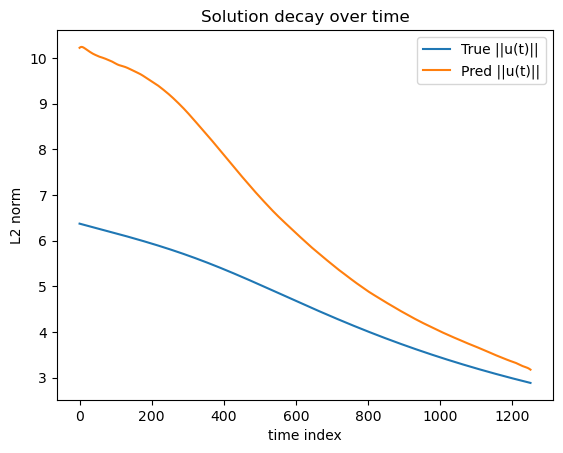

In [11]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

true_norm_t = np.linalg.norm(u_true, axis=1)
pred_norm_t = np.linalg.norm(u_pred, axis=1)

plt.plot(true_norm_t, label="True ||u(t)||")
plt.plot(pred_norm_t, label="Pred ||u(t)||")
plt.xlabel("time index")
plt.ylabel("L2 norm")
plt.legend()
plt.title("Solution decay over time")
plt.show()


In [11]:
u0_norm = np.linalg.norm(u_0[0])
rel_over_u0 = np.linalg.norm((u_0 - y_preds).ravel()) / (u0_norm * np.sqrt(u_0.size / u_0.shape[1]))
print("rel L2 wrt IC scale of nu=0.01:", rel_over_u0)


rel L2 wrt IC scale of nu=0.01: 0.3595981158714462


median rel of nu=0.01: 0.3334077170759516 max rel of nu=0.01: 0.6263996773060981


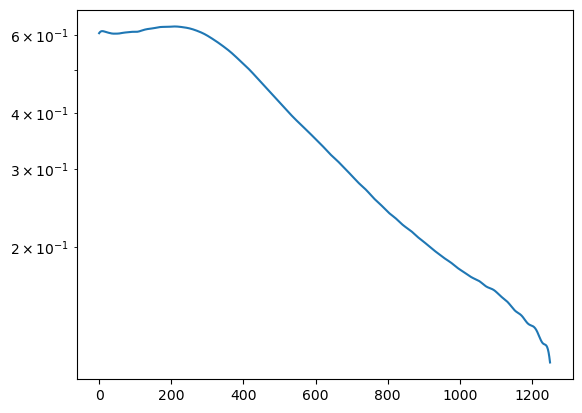

In [12]:
rel_t = np.linalg.norm(u_0 - y_preds, axis=1) / (np.linalg.norm(u_0, axis=1) + 1e-12)
print("median rel of nu=0.01:", np.median(rel_t), "max rel of nu=0.01:", rel_t.max())
plt.plot(rel_t); plt.yscale("log"); plt.show()


In [13]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

den = np.linalg.norm(u_true.ravel())
num = np.linalg.norm((u_true - u_pred).ravel())
print("abs L2 of nu=0.01:", num, "true L2 of nu=0.01:", den, "rel L2 of nu=0.01:", num/den)
print("u_true min/max of nu=0.01:", u_true.min(), u_true.max(), "std of nu=0.01:", u_true.std())
print("u_pred min/max of nu=0.01:", u_pred.min(), u_pred.max(), "std of nu=0.01:", u_pred.std())


abs L2 of nu=0.01: 81.02525862413897 true L2 of nu=0.01: 167.72703589527063 rel L2 of nu=0.01: 0.48307810480077545
u_true min/max of nu=0.01: -0.5630556139848517 0.5630556139848518 std of nu=0.01: 0.296383781363341
u_pred min/max of nu=0.01: -0.89428186 0.911622 std of nu=0.01: 0.42547175


In [15]:
print("true std of nu=0.01:", u_true.std(), "pred std of nu=0.01:", u_pred.std())


true std of nu=0.01: 0.296383781363341 pred std of nu=0.01: 0.42547175


In [16]:
251 * 128

32128

<h2>Analyze the results from PDE Nets for Inviscid Burgers</h2>

In [9]:
import torch

from neuralop.models import FNO  # or your make_fno

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FNO architecture must match what you used for training
Nx = 256      # must match config
Nt = 101
T  = 1.0
width      = 256
layers     = 4
n_modes_x  = 32
n_modes_t  = 16
in_channels  = 3
out_channels = 1

model = FNO(
    n_modes=(n_modes_t, n_modes_x),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=layers,
).to(device)

state = torch.load("sample_solution.pt", map_location=device, weights_only=False)
model.load_state_dict(state)
model.eval()


RuntimeError: Error(s) in loading state_dict for FNO:
	Missing key(s) in state_dict: "fno_blocks.convs.0.bias", "fno_blocks.convs.0.weight.tensor", "fno_blocks.convs.1.bias", "fno_blocks.convs.1.weight.tensor", "fno_blocks.convs.2.bias", "fno_blocks.convs.2.weight.tensor", "fno_blocks.convs.3.bias", "fno_blocks.convs.3.weight.tensor", "fno_blocks.fno_skips.0.conv.weight", "fno_blocks.fno_skips.1.conv.weight", "fno_blocks.fno_skips.2.conv.weight", "fno_blocks.fno_skips.3.conv.weight", "fno_blocks.channel_mlp.0.fcs.0.weight", "fno_blocks.channel_mlp.0.fcs.0.bias", "fno_blocks.channel_mlp.0.fcs.1.weight", "fno_blocks.channel_mlp.0.fcs.1.bias", "fno_blocks.channel_mlp.1.fcs.0.weight", "fno_blocks.channel_mlp.1.fcs.0.bias", "fno_blocks.channel_mlp.1.fcs.1.weight", "fno_blocks.channel_mlp.1.fcs.1.bias", "fno_blocks.channel_mlp.2.fcs.0.weight", "fno_blocks.channel_mlp.2.fcs.0.bias", "fno_blocks.channel_mlp.2.fcs.1.weight", "fno_blocks.channel_mlp.2.fcs.1.bias", "fno_blocks.channel_mlp.3.fcs.0

In [8]:
def fno_predict_u(model, v_branch, x_grid, t_grid, T, device):
    """
    v_branch: np.array (Nx_eval,)
    x_grid: np.array (Nx_eval,)
    t_grid: np.array (Nt_eval,)
    returns: u_pred (Nt_eval, Nx_eval)
    """
    model.eval()
    with torch.no_grad():
        Nx_eval = x_grid.shape[0]
        Nt_eval = t_grid.shape[0]

        v_np = v_branch.astype(np.float32)
        v_torch = torch.from_numpy(v_np).to(device)           # (Nx_eval,)
        x_torch = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        t_torch = torch.from_numpy(t_grid.astype(np.float32)).to(device)

        v_tile = v_torch[None, None, :].repeat(1, Nt_eval, 1)   # (1, Nt, Nx_eval)
        t_tile = t_torch[None, :, None].repeat(1, 1, Nx_eval)   # (1, Nt, Nx_eval)
        x_tile = x_torch[None, None, :].repeat(1, Nt_eval, 1)   # (1, Nt, Nx_eval)

        inp = torch.stack([v_tile, t_tile, x_tile], dim=1)      # (1, 3, Nt, Nx)

        u_pred = model(inp)                                     # (1, 1, Nt, Nx)
        u_pred = u_pred[0, 0].cpu().numpy()                     # (Nt, Nx)

    return u_pred


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Ground Truth


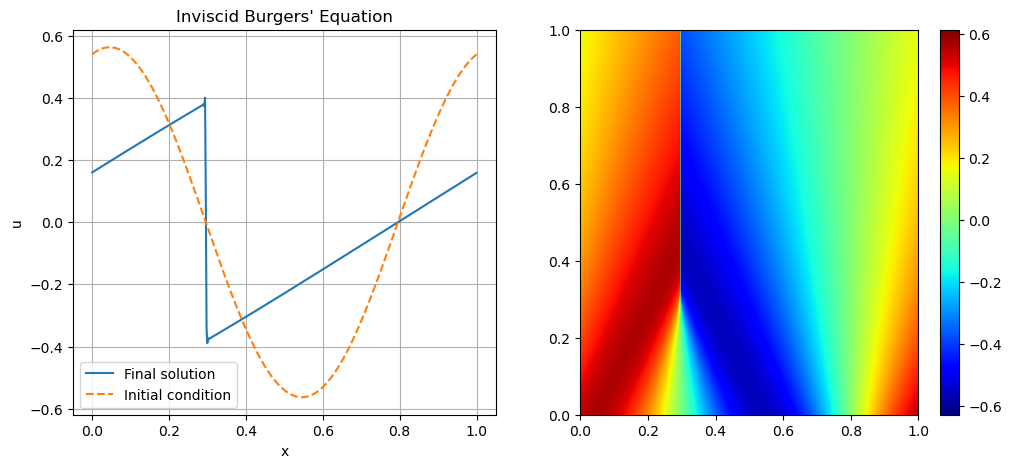

Predict


RuntimeError: Given groups=1, weight of size [256, 3, 1], expected input[1, 5, 64256] to have 3 channels, but got 5 channels instead

In [9]:
# Example usage


print("Ground Truth")
ic = lambda x : np.sin(2*np.pi*x)+np.cos(2*np.pi*x+np.ones_like(x))
u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=1, Nx=256*2, Nt=5000, plot=True) 

# Compute L2-relative error
u_0 = np.array(u_0)[::20, ::2]
Nt, Nx = u_0.shape

print("Predict")

n_pts_edge = 256
eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)
v_branch = ic(eval_pts)

# grid of predictions

x_grid = np.linspace(0, 1.0, num=Nx)
t_grid = np.linspace(0, 1.0, num=Nt)

y_preds = fno_predict_u(model, v_branch, x_grid, t_grid, 1.0, device)

# y = np.asarray(y_preds)
# if y.ndim == 2 and y.shape[1] > 1:
#     y = y[:, 1]  # u channel
# y_pred = y.reshape(n_time, n_curves)

plt.figure()
plt.imshow(y_preds, origin="lower", aspect="auto", cmap="jet", vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

print("L2-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99, ord=1))

In [15]:
v_branch[None, None, :].shape

(1, 1, 256, 1)

In [14]:
# L1 relative errors
n_pts_edge = 256

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=1)
N_case = 3000

t_max = 1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts = np.linspace(0, 1, n_pts_edge, endpoint=False)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts)


# --- Helper for PDE prediction ---
def pde_predict_grid(model, v_branch, n_pts_edge, Nx, Nt, t_max, batch=20000):
    """Predict u(x,t) directly on a rectangular grid."""
    x = np.linspace(0, 1, Nx, endpoint=False)
    t = np.linspace(0, t_max, Nt, endpoint=True)
    xv, tv = np.meshgrid(x, t)
    x_trunk = np.column_stack([xv.ravel(), tv.ravel()])

    preds = []
    for i in range(0, len(x_trunk), batch):
        xb = x_trunk[i:i+batch]
        preds.append(model.predict((v_branch.reshape(1, n_pts_edge), xb)))
    y = np.vstack(preds)
    y = np.asarray(y).squeeze()
    return y.reshape(Nt, Nx)


#---------------------------
for k in tqdm(range(N_case), desc="Processing"):
    v_branch = vs[k]            # shape (n_pts_edge,), IC at evaluation points
    plot = 0

    # (1) Compute high-res ground truth (unchanged)
    xs = np.linspace(0, 1, n_pts_edge+1, endpoint=True)
    v_branch_truth = np.append(v_branch, v_branch[0])
    u_0 = utils.numericals.solve_inviscid_burgers(
        interp1d(xs, v_branch_truth, "linear"),
        x_max=1,
        t_max=t_max,
        Nx=600,
        Nt=2400,
        plot=plot
    )
    u_truth_full = np.array(u_0)                # (Nt_high, Nx_high)
    u_truth = u_truth_full[::8, ::2]            # downsample, e.g. (Nt_truth, Nx_truth)

    # build the low-res x,t grids used for truth (matching the downsampling)
    Nt_truth, Nx_truth = u_truth.shape
    x_grid_truth = np.linspace(0, 1, Nx_truth, endpoint=False)
    t_grid_truth = np.linspace(0, t_max, Nt_truth)

    # (2) get FNO prediction on same grid
    y_pred = fno_predict_u(
        model,
        v_branch=v_branch,         # IC on eval_pts ~ length n_pts_edge
        x_grid=x_grid_truth,
        t_grid=t_grid_truth,
        T=t_max,
        device=device
    )                              # shape (Nt_truth, Nx_truth)

    # (3) compute L1 error & relative L1 error
    L1_err = np.linalg.norm(u_truth - y_pred, ord=1) / (Nx_truth * Nt_truth)
    L1_relative_err = utils.metrics.major_err(u_truth - y_pred, u_truth, 0.99, ord=1)

    # (4) adaptive refinement if you still want (optional)
    # you can reuse your "n_curves" logic, but with FNO you might not need that multi-pass.
    # For now, just keep single-shot:

    if L1_relative_err < 2e-2:
        good_cases.append(k)
    elif L1_relative_err > 5e-2:
        bad_cases.append(k)
        bad_cases_v.append(v_branch)

    if k % 10 == 0:
        print("FNO errors:")
        print(f"L1-error: {L1_err:.8f}")
        print(f"L1-relative error: {L1_relative_err:.4f}")

    L1_errs.append(L1_err)
    L1_relative_errs.append(L1_relative_err)



'''for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=600, Nt=2400, plot=plot)
            u_truth = np.array(u_0)[::8, ::2]

            y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=240, n_time=80, 
                                                              Nx=300, Nt=301, t_max=t_max, 
                                                              prev=2, fwd=2, interp="linear", plot=plot)

            # --- Model prediction ---
            y_pred = pde_predict_grid(
                model, v_branch,
                n_pts_edge=n_pts_edge,
                Nx=300, Nt=301, t_max=t_max
            )
            
            
            L1_err = np.linalg.norm(u_truth-y_pred, ord=1)/(300*301)
            L1_relative_err = utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 5e-2: #if bad, increase the resolution 
                for (Nx_test, Nt_test) in [(300, 401), (300, 501), (300, 601)]:
                    y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=600, n_time=50, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
                    y_pred_refined = pde_predict_grid(
                        model, v_branch,
                        n_pts_edge=n_pts_edge,
                        Nx=Nx_test, Nt=Nt_test, t_max=t_max
                    )
                    
        
                    L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                    if L1_relative_err > 5e-2: #still bad
                        
                        y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=1000, n_time=50, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
                        y_pred_refined = pde_predict_grid(
                            model, v_branch,
                            n_pts_edge=n_pts_edge,
                            Nx=Nx_test, Nt=Nt_test, t_max=t_max
                        )
                        
        
                        L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                        if L1_relative_err > 5e-2: # still bad
                            
                            
                            y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=900, n_time=30, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
    
                            y_pred_refined = pde_predict_grid(
                                model, v_branch,
                                n_pts_edge=n_pts_edge,
                                Nx=Nx_test, Nt=Nt_test, t_max=t_max
                            )
        
                            L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                            L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                            if L1_relative_err > 5e-2: # still bad 
                                bad_cases.append(k)
                                bad_cases_v.append(v_branch)

            if k % 10 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)'''




np.save("/home/jw3275/Characteristics-Net/errors/burgers_L1_relative_errs_PDE-burgers-256-128-FNO.npy", L1_relative_errs)
np.save("/home/jw3275/Characteristics-Net/errors/burgers_L1_errs_PDE-burgers-256-128-FNO.npy", L1_errs)

Processing:   0%|          | 0/3000 [00:00<?, ?it/s]/home/jw3275/Characteristics-Net/utils/numericals.py:29: RuntimeWarning: overflow encountered in square
  f_p1 = 0.5 * u_p1**2
/home/jw3275/Characteristics-Net/utils/numericals.py:30: RuntimeWarning: overflow encountered in square
  f_m1 = 0.5 * u_m1**2
/home/jw3275/Characteristics-Net/utils/numericals.py:33: RuntimeWarning: invalid value encountered in subtract
  u = 1/100 * (u_p1 + 98*u + u_m1) - (dt / (2 * dx)) * (f_p1 - f_m1)
/home/jw3275/Characteristics-Net/utils/numericals.py:33: RuntimeWarning: invalid value encountered in add
  u = 1/100 * (u_p1 + 98*u + u_m1) - (dt / (2 * dx)) * (f_p1 - f_m1)
Processing:   0%|          | 0/3000 [00:00<?, ?it/s]


RuntimeError: stack expects each tensor to be equal size, but got [1, 301, 256] at entry 0 and [1, 301, 300] at entry 1

In [14]:
L1_relative_errs = np.load("/home/jw3275/Characteristics-Net/errors/burgers_L1_relative_errs_PDE_4_256_200_v_1.0_t_1.0.npy")
L1_errs = np.load("/home/jw3275/Characteristics-Net/errors/burgers_L1_errs_PDE_4_256_200_v_1.0_t_1.0.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(sorted(L1_relative_errs))[:1500]
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

----------------------------------------------------------------------------------------------------

Average L1 relative error is 0.5410

Min/Max L1 relative error is 0.1716, 0.9015

----------------------------------------------------------------------------------------------------

Average L1 error is 0.0016

Min/Max L1 error is 0.0007, 0.0041

----------------------------------------------------------------------------------------------------


In [15]:
np.median(L1_relative_errs)

0.5384889247245357

In [16]:
np.std(L1_relative_errs)

0.13859690231552502

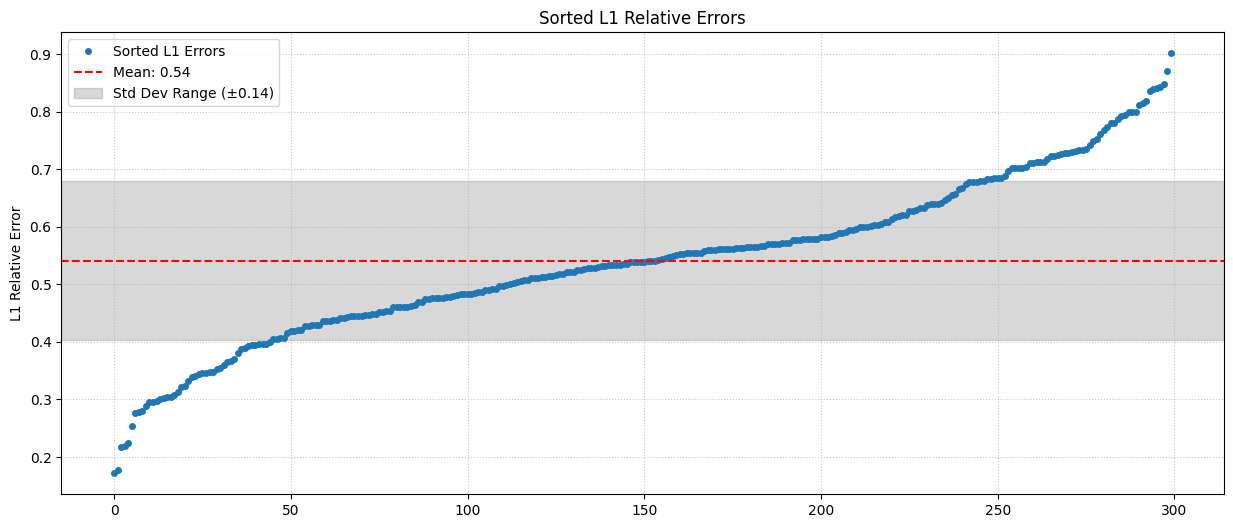

In [17]:
# --- Calculations ---
L1_relative_errs = sorted(L1_relative_errs)[:1500]

# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_relative_errs)
std_err = np.std(L1_relative_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

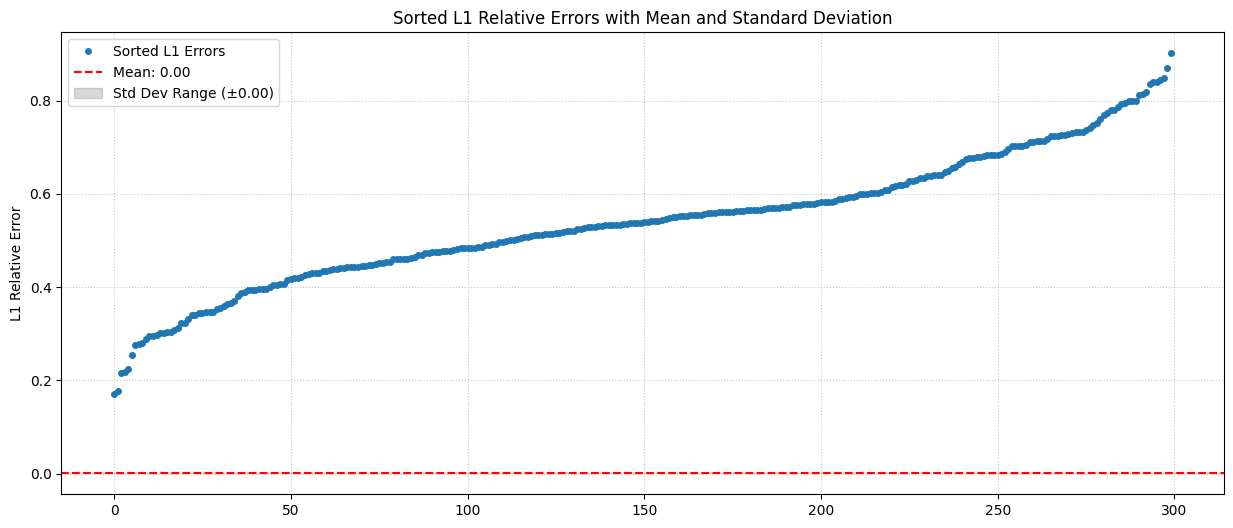

In [18]:
# --- Calculations ---
# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_errs)
std_err = np.std(L1_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors with Mean and Standard Deviation')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

<h2>Load another models for more complicated initial condition</h2>

In [4]:
n_pts_edge_1 = 200

net = dde.nn.DeepONet(
    [n_pts_edge_1] + [100] * 4,
    [2] + [100] * 4,
    "tanh",
    "Glorot normal",
    num_outputs=2,
    multi_output_strategy="independent"
)

# Model
model_1 = dde.Model(data, net)
model_1.compile("adam", lr=0.001)
model_1.restore("trained_models/burgers-100-4-ctn-50000.pt")

Compiling model...
'compile' took 0.000282 s



In [18]:
n_pts_edge_1 = 250

net = dde.nn.DeepONet(
    [n_pts_edge_1] + [64] * 4,
    [2] + [64] * 4,
    "tanh",
    "Glorot normal",
    num_outputs=2,
    multi_output_strategy="independent"
)

# Model
model_1 = dde.Model(data, net)
model_1.compile("adam", lr=0.001)
model_1.restore("trained_models/burgers-64-4-larger-ctn-50000.pt")

Compiling model...
'compile' took 0.000284 s



Plotting


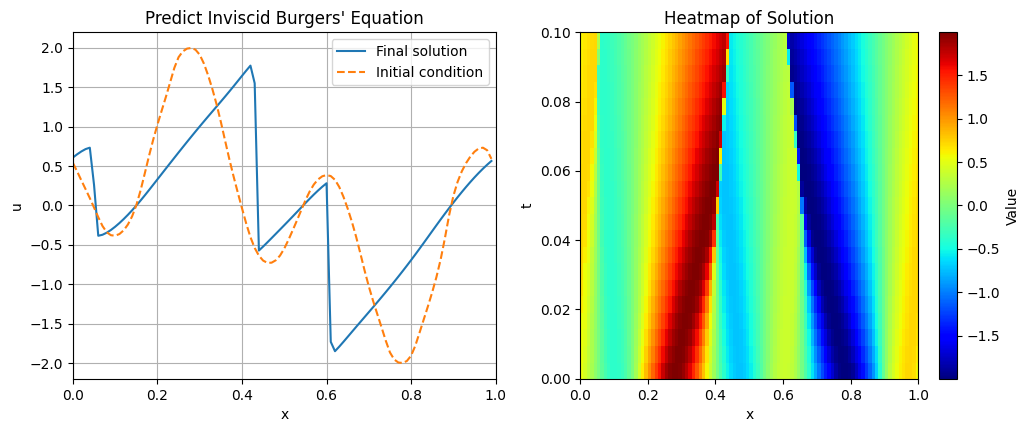

Ground Truth


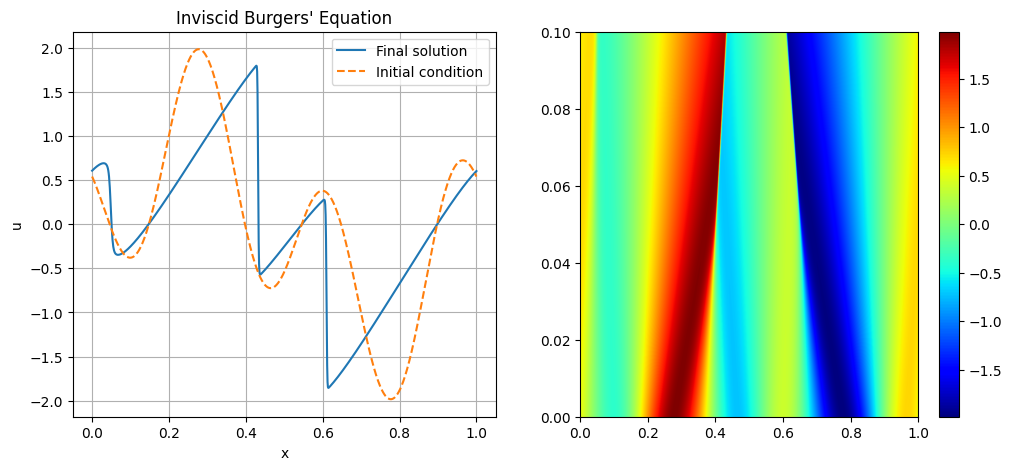

L2-relative erros:  0.032830852691874426
L1-relative erros:  0.02212827658315098


In [14]:
# Example usage

ic = lambda x : np.sin(2*np.pi*x)+np.cos(6*np.pi*x+np.ones_like(x))
eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
v_branch = ic(eval_pts)

n_curves = 800
n_time = 16

# Predict and process the solution

u_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1,
                                                  n_curves, n_time, 
                                                  100, 21,
                                                  x_min=0.0, x_max=1.0, t_max=0.1,
                                                  prev=1, fwd=1,
                                                  interp="linear", plot=True)

print("Ground Truth")
u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=0.1, Nx=1000, Nt=10000, plot=True) 

# Compute L2-relative error
u_0 = np.array(u_0)[::500, ::10]
print("L2-relative erros: ", utils.metrics.major_err(u_0[-1]-u_pred[-1], u_0[-1], 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0[-1]-u_pred[-1], u_0[-1], 0.99, ord=1))

In [ ]:
# L1 relative errors

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=0.55)
N_case = 3000

t_max = 0.1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts_1 = np.linspace(0, 1, n_pts_edge_1)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts_1)

for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=600, Nt=2000, plot=plot)
            u_truth = np.array(u_0)[::40, ::3]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=200, n_time=40, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth-y_pred, ord=1)/(200*51)
            L1_relative_err = utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 7e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=300, n_time=30, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                if L1_relative_err > 7e-2: #still bad
                    y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=600, n_time=25, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                    L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                    if L1_relative_err > 7e-2: # still bad
                        y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=15, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                        L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                        if L1_relative_err > 7e-2: # still bad 
                            bad_cases.append(k)
                            bad_cases_v.append(v_branch)

            if k % 250 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.55_t_0.1.npy", L1_relative_errs)
np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.55_t_0.1.npy", L1_errs)

Processing:   2%|▏         | 1/50 [00:00<00:14,  3.29it/s]

Characteristic net errors:
L1-error:  0.00042206
L1-relative error:  0.0484


Processing:  22%|██▏       | 11/50 [00:04<00:15,  2.44it/s]

Characteristic net errors:
L1-error:  0.00653421
L1-relative error:  0.0452


Processing:  42%|████▏     | 21/50 [00:11<00:23,  1.22it/s]

...

Characteristic net errors:
L1-error:  0.00036514
L1-relative error:  0.0294


Processing:  82%|████████▏ | 41/50 [00:25<00:05,  1.50it/s]

Characteristic net errors:
L1-error:  0.00065399
L1-relative error:  0.0474


Processing: 100%|██████████| 50/50 [00:34<00:00,  1.43it/s]

----------------------------------------------------------------------------------------------------

Average L1 relative error is 0.0531

Min/Max L1 relative error is 0.0156, 0.1101

----------------------------------------------------------------------------------------------------

Average L1 error is 0.0020

Min/Max L1 error is 0.0001, 0.0078

----------------------------------------------------------------------------------------------------


In [23]:
L1_relative_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.55_t_0.1_last.npy")
L1_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.55_t_0.1_last.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

----------------------------------------------------------------------------------------------------

Average L1 relative error is 0.0546

Min/Max L1 relative error is 0.0074, 0.2726

----------------------------------------------------------------------------------------------------

Average L1 error is 0.0009

Min/Max L1 error is 0.0002, 0.0050

----------------------------------------------------------------------------------------------------


In [ ]:
# L1 relative errors

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=0.58)
N_case = 3000

t_max = 0.1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts_1 = np.linspace(0, 1, n_pts_edge_1)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts_1)

for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=1000, Nt=10000, plot=plot)
            u_truth = np.array(u_0)[::200, ::5]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=250, n_time=16, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200)
            L1_relative_err = utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 4.5e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=16, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                if L1_relative_err > 4.5e-2: #still bad
                    y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=1000, n_time=16, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                    L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                    if L1_relative_err > 4.5e-2: # still bad
                        y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=11, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                        L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                        if L1_relative_err > 4.5e-2: # still bad 

                            # L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)
                            # print(f"Bad case L1-error initial: {L1_initial : .8f}")
                            
                            bad_cases.append(k)
                            bad_cases_v.append(v_branch)

            if k % 250 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.58_t_0.1_last_64.npy", L1_relative_errs)
np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.58_t_0.1_last_64.npy", L1_errs)

Processing:   0%|          | 1/3000 [00:00<32:28,  1.54it/s]

Characteristic net errors:
L1-error:  0.03213715
L1-relative error:  0.0440


Processing:   8%|▊         | 251/3000 [06:49<1:39:08,  2.16s/it]

Characteristic net errors:
L1-error:  0.04695555
L1-relative error:  0.0449


Processing:  17%|█▋        | 501/3000 [13:18<38:55,  1.07it/s]  

Characteristic net errors:
L1-error:  0.02217038
L1-relative error:  0.0197


Processing:  23%|██▎       | 695/3000 [19:07<1:20:56,  2.11s/it]

In [14]:
np.median(L1_relative_errs)

np.float64(0.036839066290153925)

In [33]:
len(L1_relative_errs)

200

In [34]:
# Number of cases with L1-relative errors < 4.5%
(len(L1_relative_errs) - len(bad_cases)) / len(L1_relative_errs)

0.6

In [19]:
print("-" * 100)
print("\nNumber of trainable parameters: ", sum(p.numel() for p in net.parameters()))
print("\n" + "-" * 100)

----------------------------------------------------------------------------------------------------

Number of trainable parameters:  82434

----------------------------------------------------------------------------------------------------


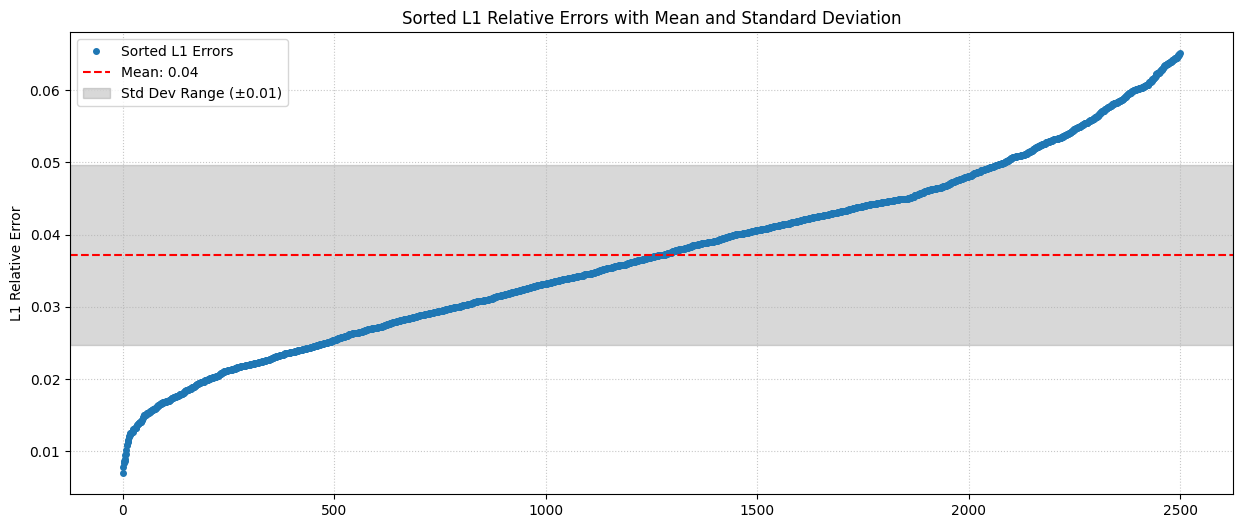

In [13]:
# --- Calculations ---
L1_relative_errs = sorted(L1_relative_errs)[:2500]
# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_relative_errs)
std_err = np.std(L1_relative_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors with Mean and Standard Deviation')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [15]:
mean_err

np.float64(0.03712621841240561)

In [16]:
std_err

np.float64(0.012435287190518592)

In [12]:
L1_relative_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.6_t_0.1_last_64.npy")
L1_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.6_t_0.1_last_64.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

----------------------------------------------------------------------------------------------------

Average L1 relative error is 0.0450

Min/Max L1 relative error is 0.0069, 0.1794

----------------------------------------------------------------------------------------------------

Average L1 error is 0.0364

Min/Max L1 error is 0.0084, 0.1134

----------------------------------------------------------------------------------------------------


Processing:   0%|          | 0/5 [00:00<?, ?it/s]

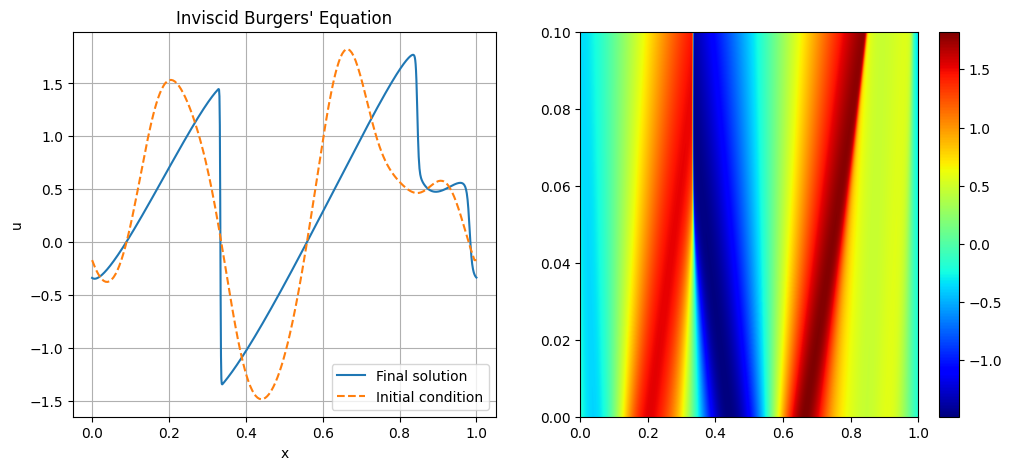

Plotting


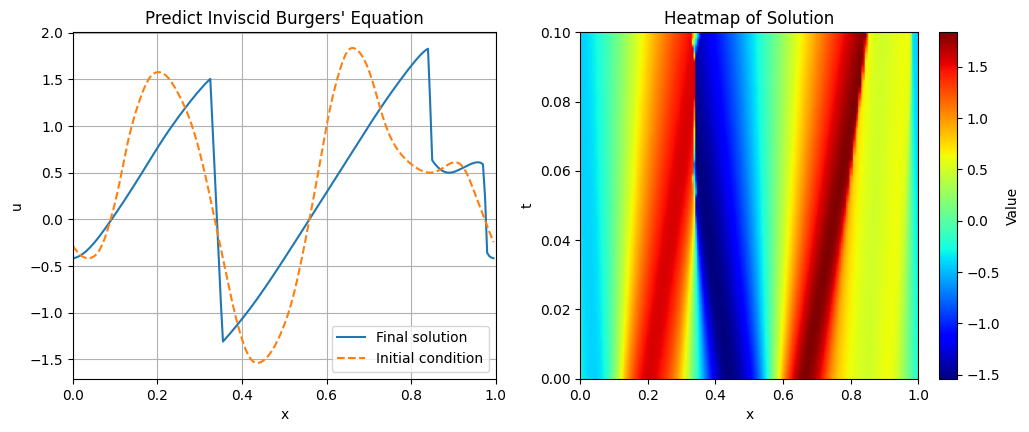

Characteristic net errors:
L1-error initial:  0.04597410
L1-relative error last:  0.0751
Plotting


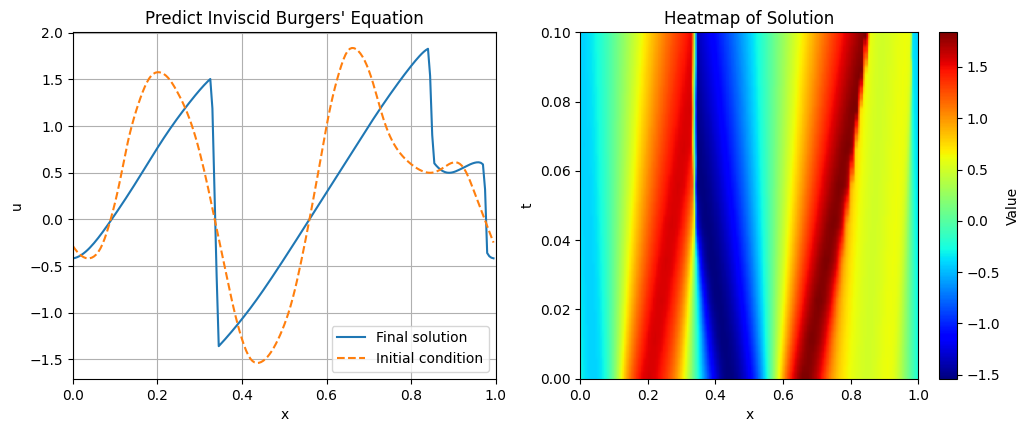

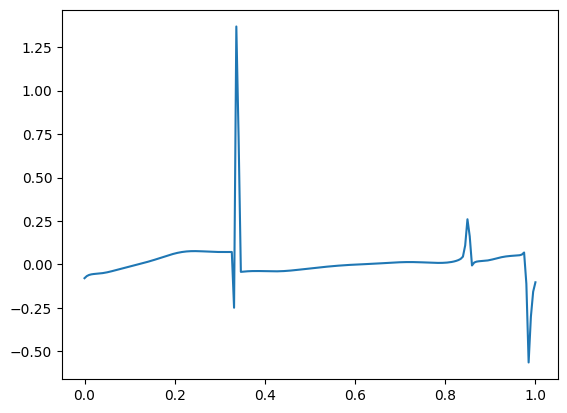

Processing:  20%|██        | 1/5 [00:02<00:11,  2.99s/it]

Characteristic net errors:
L1-error initial:  0.04631944
L1-relative error last:  0.0618


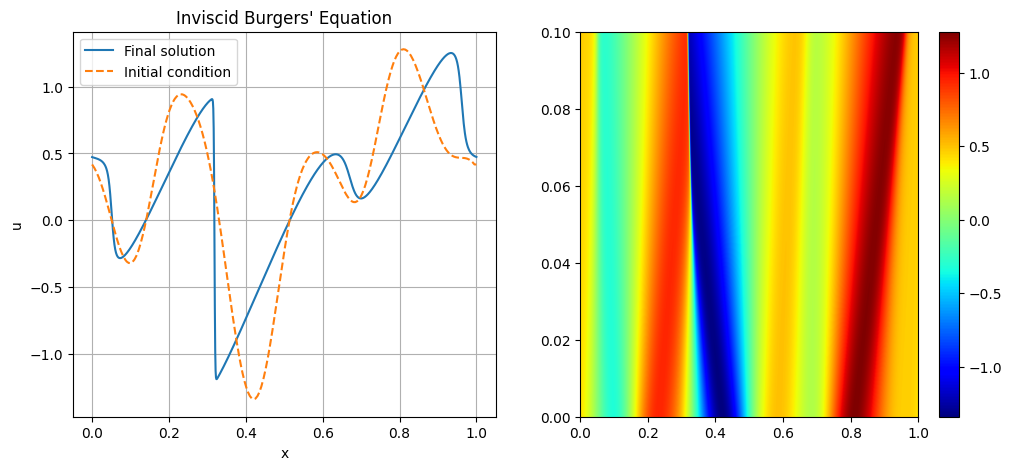

Plotting


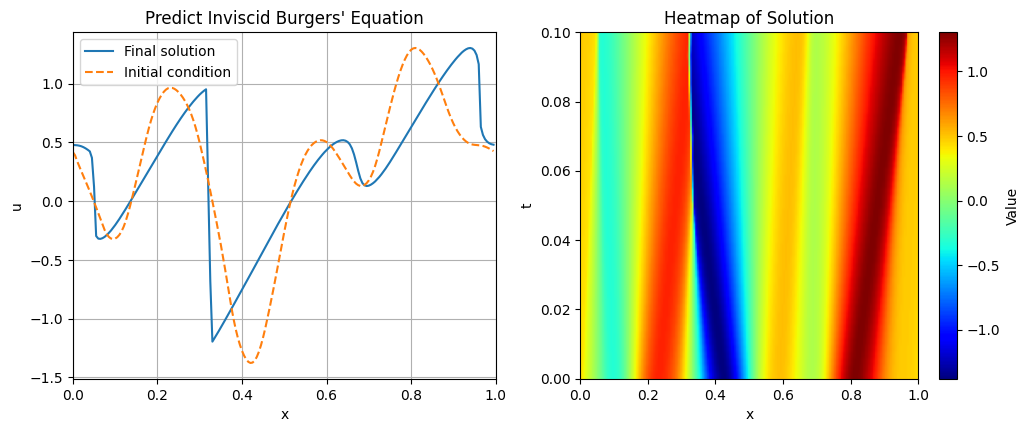

Characteristic net errors:
L1-error initial:  0.03032296
L1-relative error last:  0.0603
Plotting


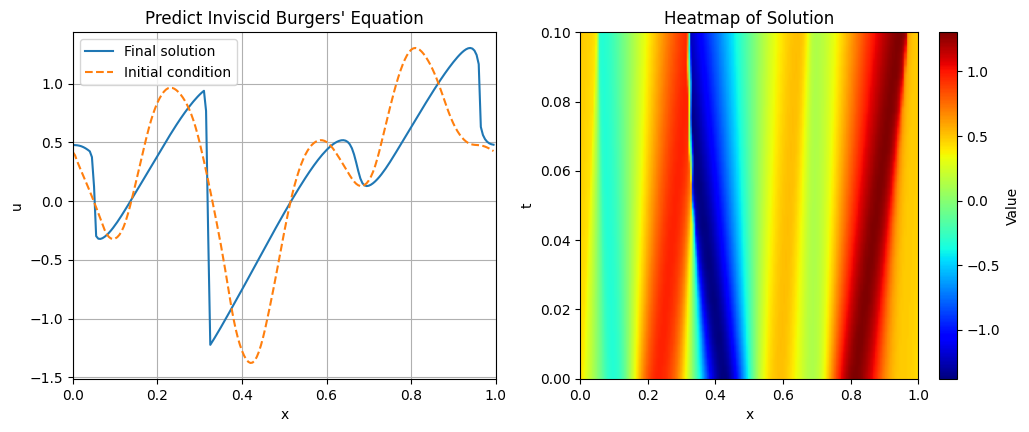

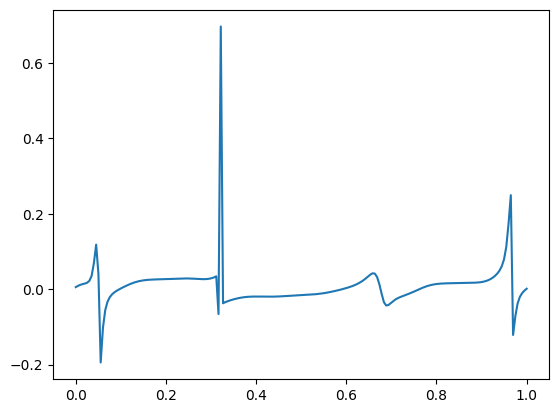

Processing:  40%|████      | 2/5 [00:05<00:08,  2.88s/it]

Characteristic net errors:
L1-error initial:  0.03096229
L1-relative error last:  0.0514


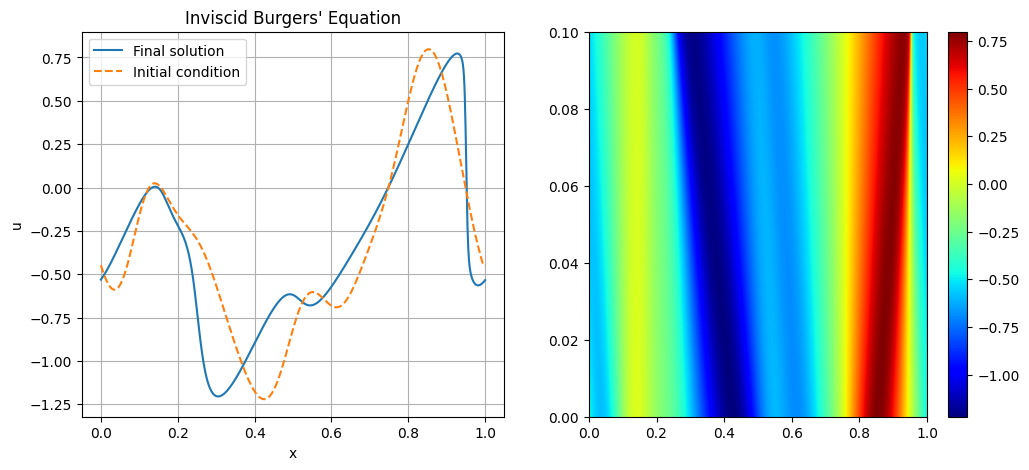

Plotting


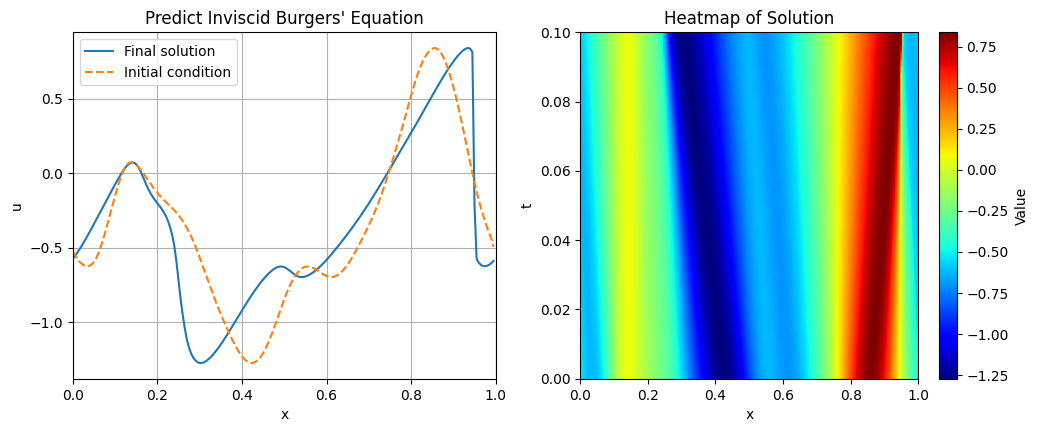

Characteristic net errors:
L1-error initial:  0.04933452
L1-relative error last:  0.0542
Plotting


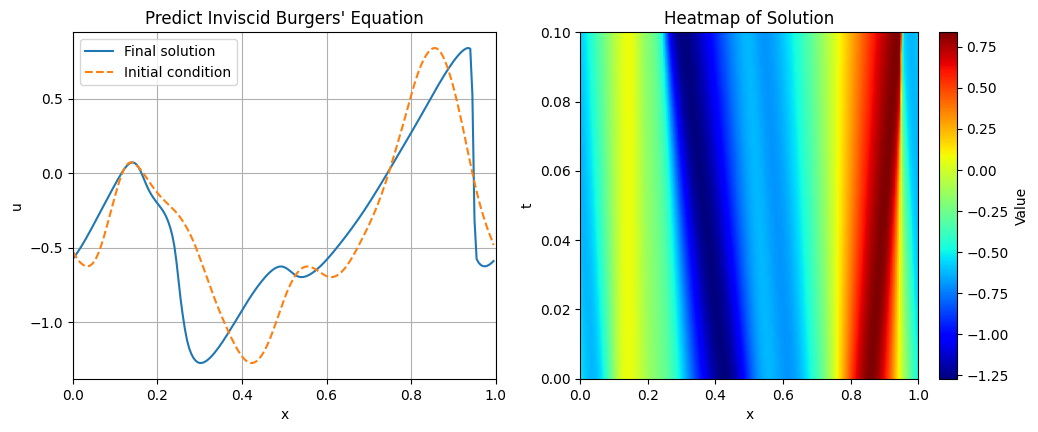

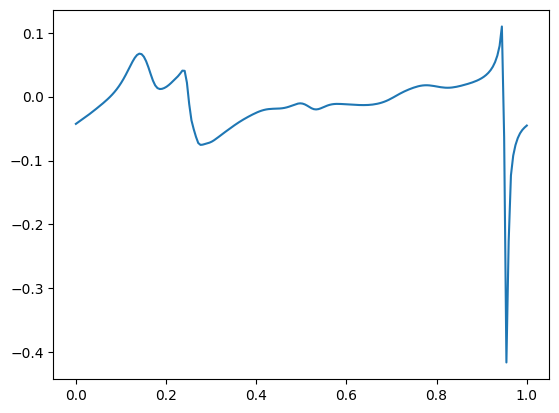

Processing:  60%|██████    | 3/5 [00:08<00:05,  2.89s/it]

Characteristic net errors:
L1-error initial:  0.04947547
L1-relative error last:  0.0529


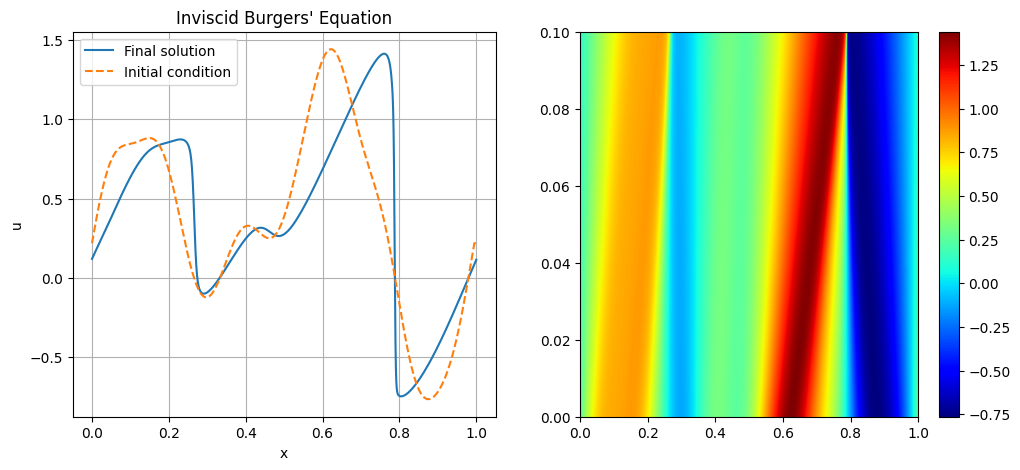

Plotting


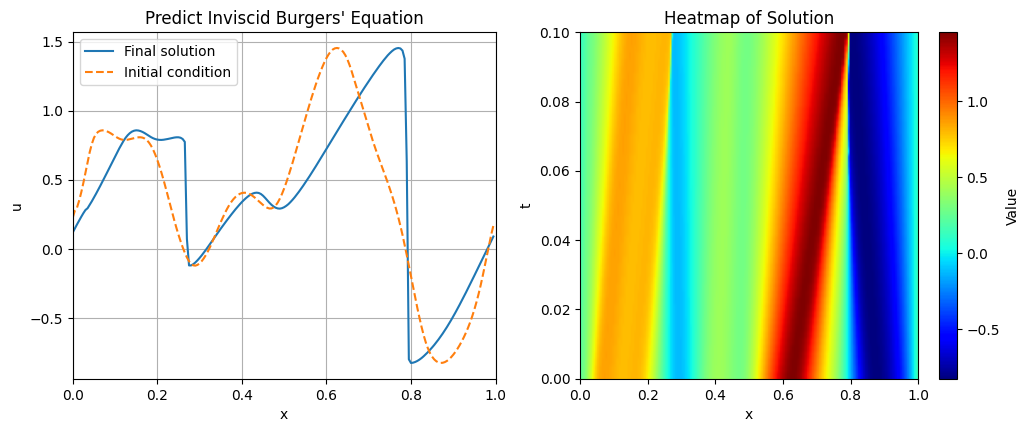

Characteristic net errors:
L1-error initial:  0.07649586
L1-relative error last:  0.0969
Plotting


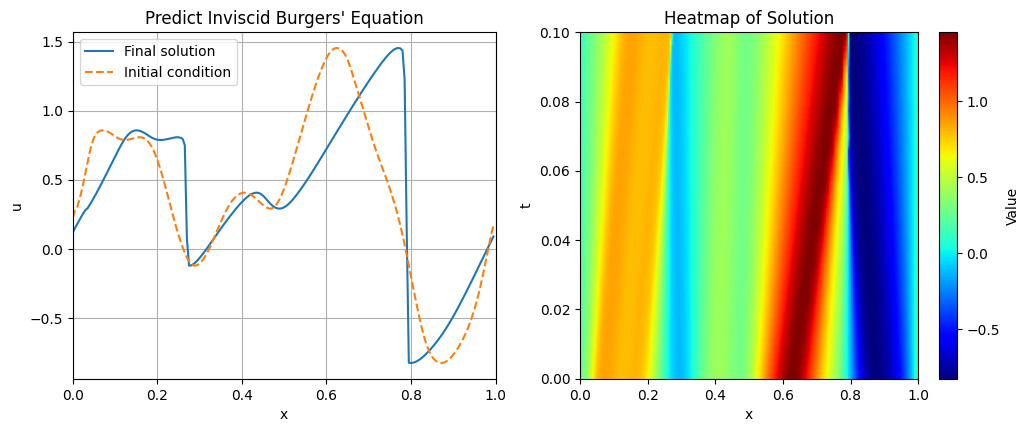

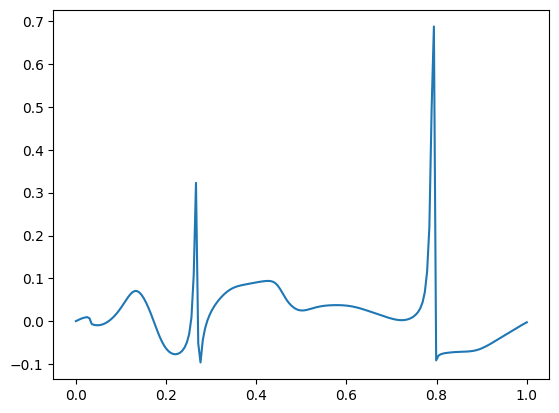

Processing:  80%|████████  | 4/5 [00:11<00:02,  2.94s/it]

Characteristic net errors:
L1-error initial:  0.07659844
L1-relative error last:  0.0909


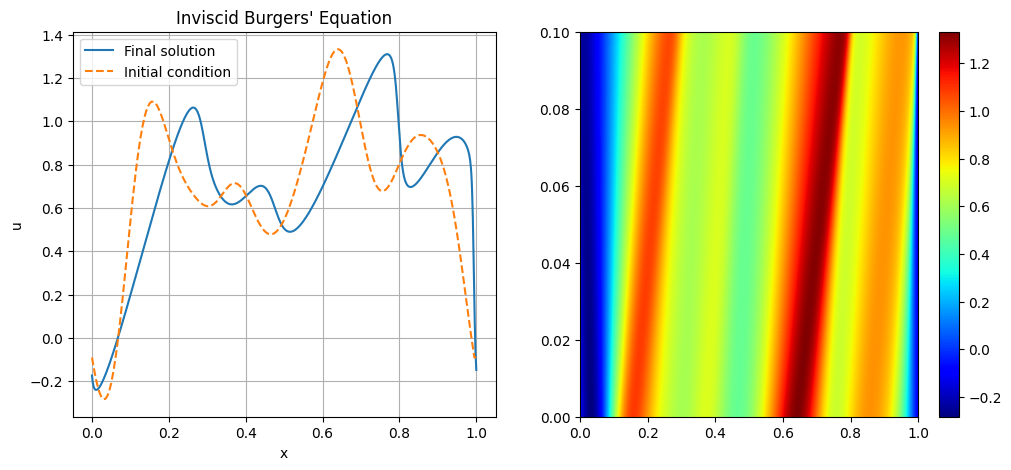

Plotting


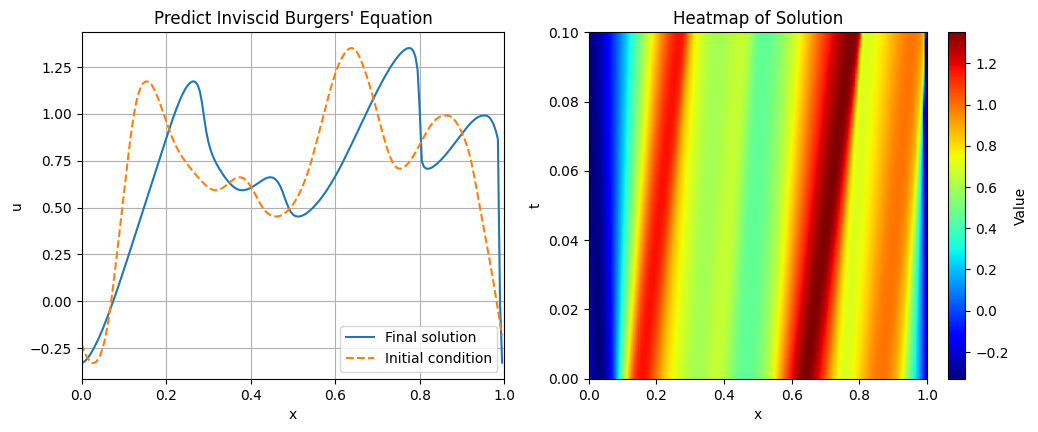

Characteristic net errors:
L1-error initial:  0.05257725
L1-relative error last:  0.0543
Plotting


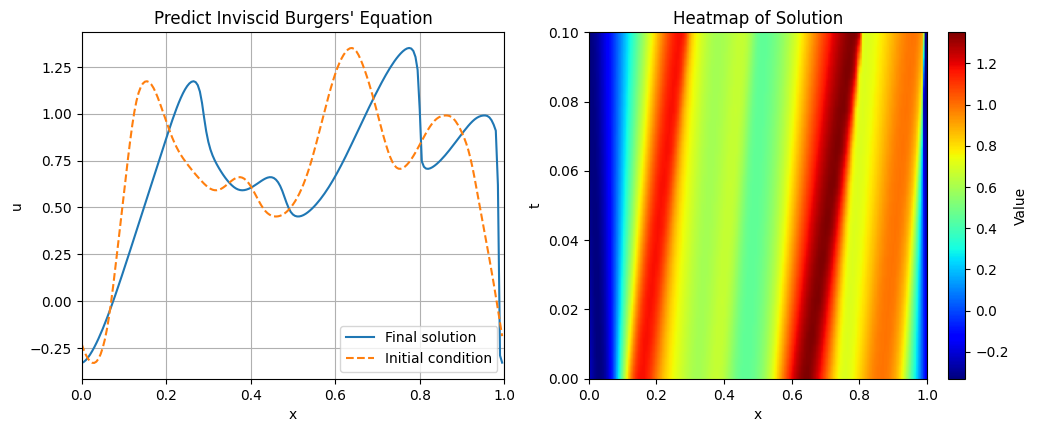

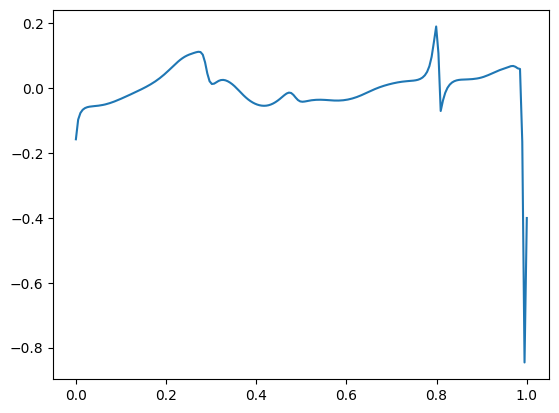

Processing: 100%|██████████| 5/5 [00:14<00:00,  2.94s/it]

Characteristic net errors:
L1-error initial:  0.05278050
L1-relative error last:  0.0543


In [15]:
for k in tqdm(bad_cases[5:10], desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        if True:
            plot = 1
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=1000, Nt=10000, plot=plot)
            u_truth = np.array(u_0)[::200, ::5]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=200, n_time=15, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200*51)
            L1_relative_err = utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1) 

            L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)

            if k % 1 == 0:
                print("Characteristic net errors:")
                print(f"L1-error initial: {L1_initial : .8f}")
                print(f"L1-relative error last: {L1_relative_err : .4f}") 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 4e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=10, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200*51))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                plt.plot(np.linspace(0, 1, 200), y_pred[-1] - u_truth[-1])
                plt.show()

                L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)

                if k % 1 == 0:
                    print("Characteristic net errors:")
                    print(f"L1-error initial: {L1_initial : .8f}")
                    print(f"L1-relative error last: {L1_relative_err : .4f}") 
